In [2]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.5 MB/s eta 0:00:00


In [3]:
import ultralytics

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [10]:
import os

# List the contents of the mounted Google Drive
print(os.listdir('/content/gdrive/MyDrive/asl_dataset'))

['u', 's', '7', '9', '0', 'a', 't', 'r', '.DS_Store', '3', 'e', 'c', 'v', 'w', '2', 'p', 'q', 'y', 'l', 'b', 'k', '5', 'x', 'd', '4', 'f', 'z', 'j', 'o', 'h', 'm', '1', 'g', '8', '6', 'i', 'n']


In [11]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define source and destination paths
original_dataset_path = '/content/gdrive/MyDrive/asl_dataset'
ultralytics_dataset_path = '/content/asl_ultralytics_format'

# Create the main Ultralytics-compatible directory if it doesn't exist
if not os.path.exists(ultralytics_dataset_path):
    os.makedirs(ultralytics_dataset_path)
    print(f"Created directory: {ultralytics_dataset_path}")
else:
    print(f"Directory already exists: {ultralytics_dataset_path}")

# Define train, val, test split ratios
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1


Created directory: /content/asl_ultralytics_format


In [12]:
# Get list of class folders (excluding non-directories like .DS_Store)
class_names = [d for d in os.listdir(original_dataset_path) if os.path.isdir(os.path.join(original_dataset_path, d))]
print(f"Found {len(class_names)} classes: {class_names}")

# Iterate through each class and split/copy images
for class_name in class_names:
    class_path = os.path.join(original_dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f)) and not f.startswith('.')]

    if not images:
        print(f"Warning: No images found for class '{class_name}'. Skipping.")
        continue

    # Split data
    train_val_images, test_images = train_test_split(images, test_size=test_ratio, random_state=42)
    train_images, val_images = train_test_split(train_val_images, test_size=val_ratio / (train_ratio + val_ratio), random_state=42)

    splits = {
        'train': train_images,
        'val': val_images,
        'test': test_images
    }

    for split_name, image_list in splits.items():
        destination_dir = os.path.join(ultralytics_dataset_path, split_name, class_name)
        os.makedirs(destination_dir, exist_ok=True)

        for image_name in image_list:
            src_path = os.path.join(class_path, image_name)
            dst_path = os.path.join(destination_dir, image_name)
            shutil.copy(src_path, dst_path)

    print(f"Processed class '{class_name}': Train {len(train_images)}, Val {len(val_images)}, Test {len(test_images)} images.")

print("Dataset conversion to Ultralytics format complete!")


Found 36 classes: ['u', 's', '7', '9', '0', 'a', 't', 'r', '3', 'e', 'c', 'v', 'w', '2', 'p', 'q', 'y', 'l', 'b', 'k', '5', 'x', 'd', '4', 'f', 'z', 'j', 'o', 'h', 'm', '1', 'g', '8', '6', 'i', 'n']
Processed class 'u': Train 55, Val 8, Test 7 images.
Processed class 's': Train 55, Val 8, Test 7 images.
Processed class '7': Train 55, Val 8, Test 7 images.
Processed class '9': Train 55, Val 8, Test 7 images.
Processed class '0': Train 55, Val 8, Test 7 images.
Processed class 'a': Train 55, Val 8, Test 7 images.
Processed class 't': Train 51, Val 7, Test 7 images.
Processed class 'r': Train 55, Val 8, Test 7 images.
Processed class '3': Train 55, Val 8, Test 7 images.
Processed class 'e': Train 55, Val 8, Test 7 images.
Processed class 'c': Train 55, Val 8, Test 7 images.
Processed class 'v': Train 55, Val 8, Test 7 images.
Processed class 'w': Train 55, Val 8, Test 7 images.
Processed class '2': Train 55, Val 8, Test 7 images.
Processed class 'p': Train 55, Val 8, Test 7 images.
Proces

In [13]:
pip install albumentations

In [14]:
import albumentations as A
import cv2
import os

# Define the augmentation pipeline
transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7), # Brightness/Contrast changes
    A.Rotate(limit=15, p=0.7), # Small rotations (up to 15 degrees)
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=0, p=0.7), # Scaling (and slight shift)
    A.RandomCrop(height=224, width=224, p=0.7), # Cropping (adjust size as needed)
    A.GaussianBlur(blur_limit=(3, 7), p=0.5), # Blur
    # For 'background variation', if the images have backgrounds, we might need more complex techniques
    # or a dataset with various backgrounds. For now, general geometric/color augmentations are applied.
    # If specific background images are available, a custom augmentation could be built.

    # Resize to a common size, if not already handled by RandomCrop
    A.Resize(256, 256, p=1.0) # Ensure images are a consistent size, e.g., for model input
])

# Path to the training data within the Ultralytics format
train_dir = os.path.join(ultralytics_dataset_path, 'train')

# Number of augmented copies per original image
num_aug_copies = 2 # Augment each image 2 times

print(f"Applying augmentations to images in: {train_dir}")
print(f"Each image will be augmented {num_aug_copies} times.")


Applying augmentations to images in: /content/asl_ultralytics_format/train
Each image will be augmented 2 times.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


The code above defines an augmentation pipeline using `albumentations` with transformations like random brightness/contrast, rotations, shifts, scaling, random cropping, and Gaussian blur. Each original image in the training set will be augmented a specified number of times.

In [15]:
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if not os.path.exists(class_path):
        print(f"Warning: Class path not found: {class_path}. Skipping.")
        continue

    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f)) and not f.startswith('.')]
    if not images:
        print(f"No images found in {class_path}. Skipping augmentation for this class.")
        continue

    print(f"Augmenting class: {class_name} with {len(images)} original images...")

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        for i in range(num_aug_copies):
            augmented_image = transform(image=image)['image']
            # Convert back to BGR for saving with OpenCV
            augmented_image_bgr = cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR)

            # Save augmented image with a distinct name
            base_name, ext = os.path.splitext(img_name)
            aug_img_name = f"{base_name}_aug_{i}{ext}"
            aug_img_path = os.path.join(class_path, aug_img_name)
            cv2.imwrite(aug_img_path, augmented_image_bgr)
    print(f"Finished augmenting class: {class_name}")

print("Data augmentation complete for training set!")


Augmenting class: u with 55 original images...
Finished augmenting class: u
Augmenting class: s with 55 original images...
Finished augmenting class: s
Augmenting class: 7 with 55 original images...
Finished augmenting class: 7
Augmenting class: 9 with 55 original images...
Finished augmenting class: 9
Augmenting class: 0 with 55 original images...
Finished augmenting class: 0
Augmenting class: a with 55 original images...
Finished augmenting class: a
Augmenting class: t with 51 original images...
Finished augmenting class: t
Augmenting class: r with 55 original images...
Finished augmenting class: r
Augmenting class: 3 with 55 original images...
Finished augmenting class: 3
Augmenting class: e with 55 original images...
Finished augmenting class: e
Augmenting class: c with 55 original images...
Finished augmenting class: c
Augmenting class: v with 55 original images...
Finished augmenting class: v
Augmenting class: w with 55 original images...
Finished augmenting class: w
Augmenting c

The script has now iterated through each class in your training set, applied the defined augmentations to each image, and saved the augmented copies back into their respective class folders. This process effectively expands your training data, which can lead to more robust model training.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the base path to the Ultralytics-formatted dataset
ultralytics_dataset_path = '/content/asl_ultralytics_format'

def count_images_per_class(base_path, split_type):
    counts = {}
    split_path = os.path.join(base_path, split_type)
    if not os.path.exists(split_path):
        print(f"Warning: {split_path} does not exist. Skipping {split_type}.")
        return counts

    for class_name in os.listdir(split_path):
        class_dir = os.path.join(split_path, class_name)
        if os.path.isdir(class_dir):
            num_images = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f)) and not f.startswith('.')])
            counts[class_name] = num_images
    return counts

# Get counts for each split
train_counts = count_images_per_class(ultralytics_dataset_path, 'train')
val_counts = count_images_per_class(ultralytics_dataset_path, 'val')
test_counts = count_images_per_class(ultralytics_dataset_path, 'test')

# Convert to DataFrames for easier plotting
train_df = pd.DataFrame(list(train_counts.items()), columns=['Class', 'Count']).sort_values('Class')
val_df = pd.DataFrame(list(val_counts.items()), columns=['Class', 'Count']).sort_values('Class')
test_df = pd.DataFrame(list(test_counts.items()), columns=['Class', 'Count']).sort_values('Class')

print("Train Set Class Counts:")
print(train_df.head())
print("\nValidation Set Class Counts:")
print(val_df.head())
print("\nTest Set Class Counts:")
print(test_df.head())


Train Set Class Counts:
   Class  Count
18     0    165
24     1    165
34     2    165
31     3    165
11     4    165

Validation Set Class Counts:
   Class  Count
18     0      8
24     1      8
34     2      8
31     3      8
11     4      8

Test Set Class Counts:
   Class  Count
18     0      7
24     1      7
34     2      7
31     3      7
11     4      7


The code above counts the number of images for each class in the `train`, `val`, and `test` directories and displays the first few entries of these counts. Next, we will visualize these distributions using bar plots.

/tmp/ipykernel_2144/3475916112.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=train_df, palette='viridis')


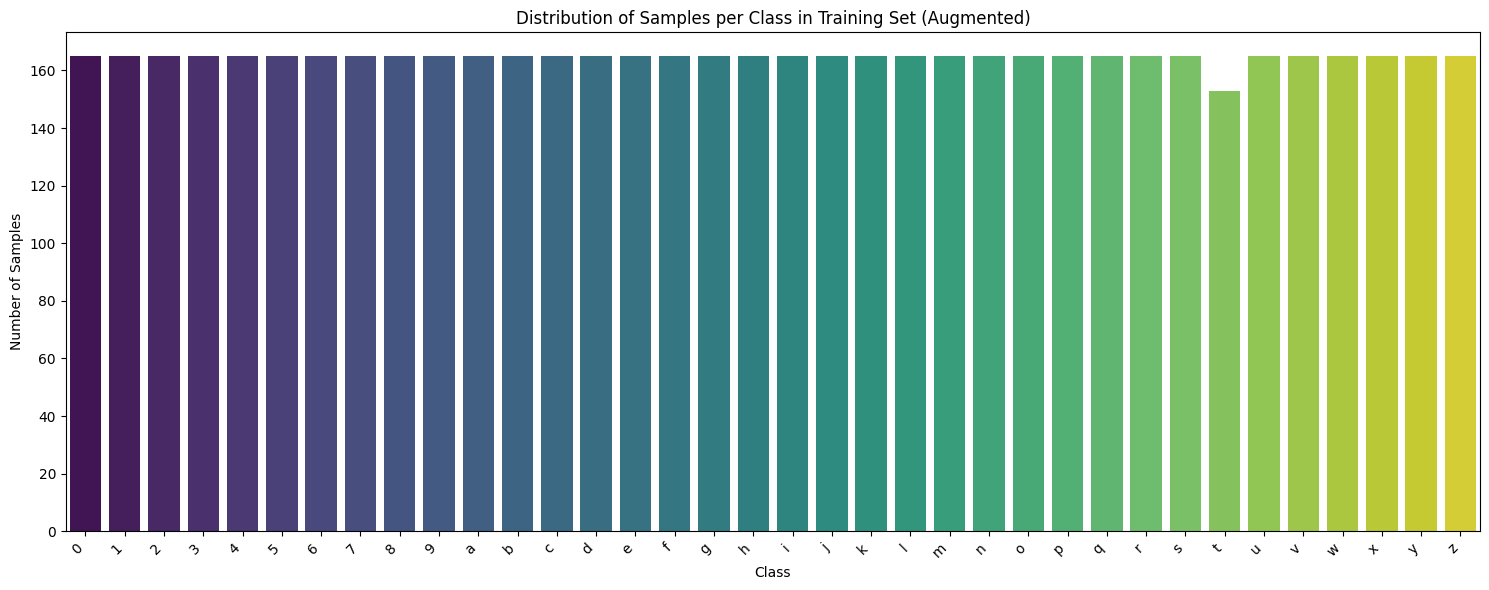

/tmp/ipykernel_2144/3475916112.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=val_df, palette='plasma')


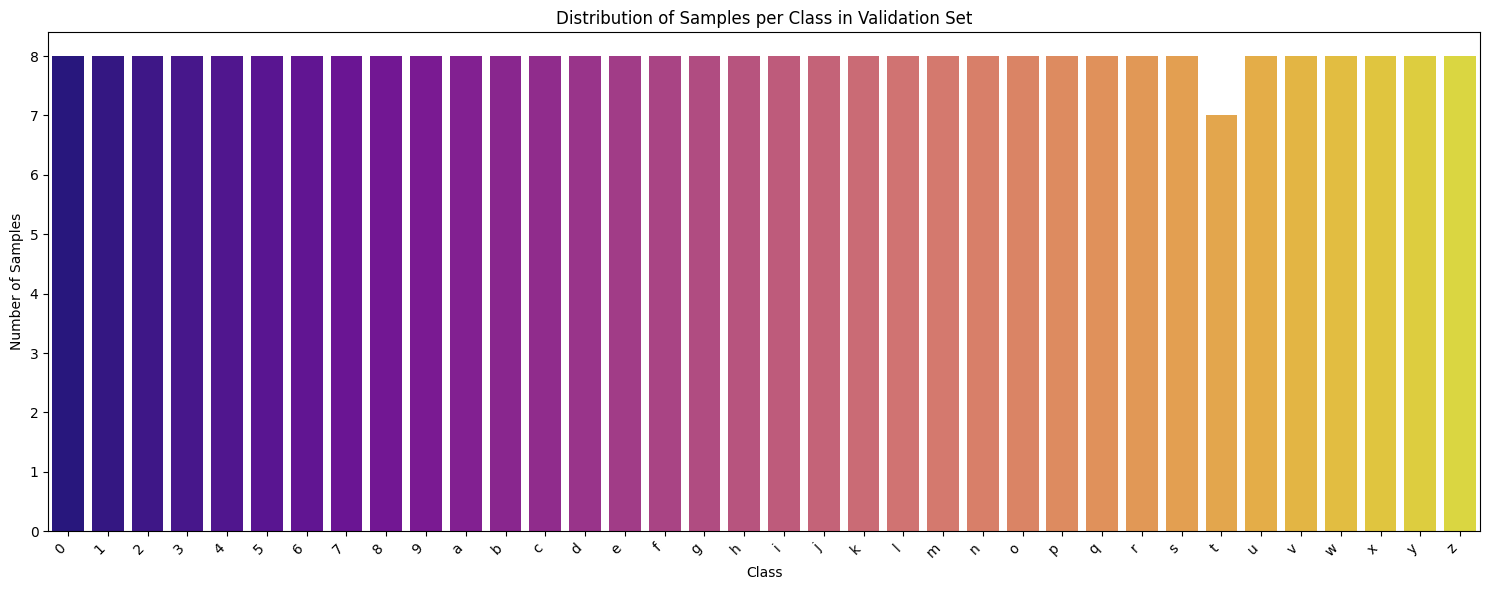

/tmp/ipykernel_2144/3475916112.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=test_df, palette='magma')


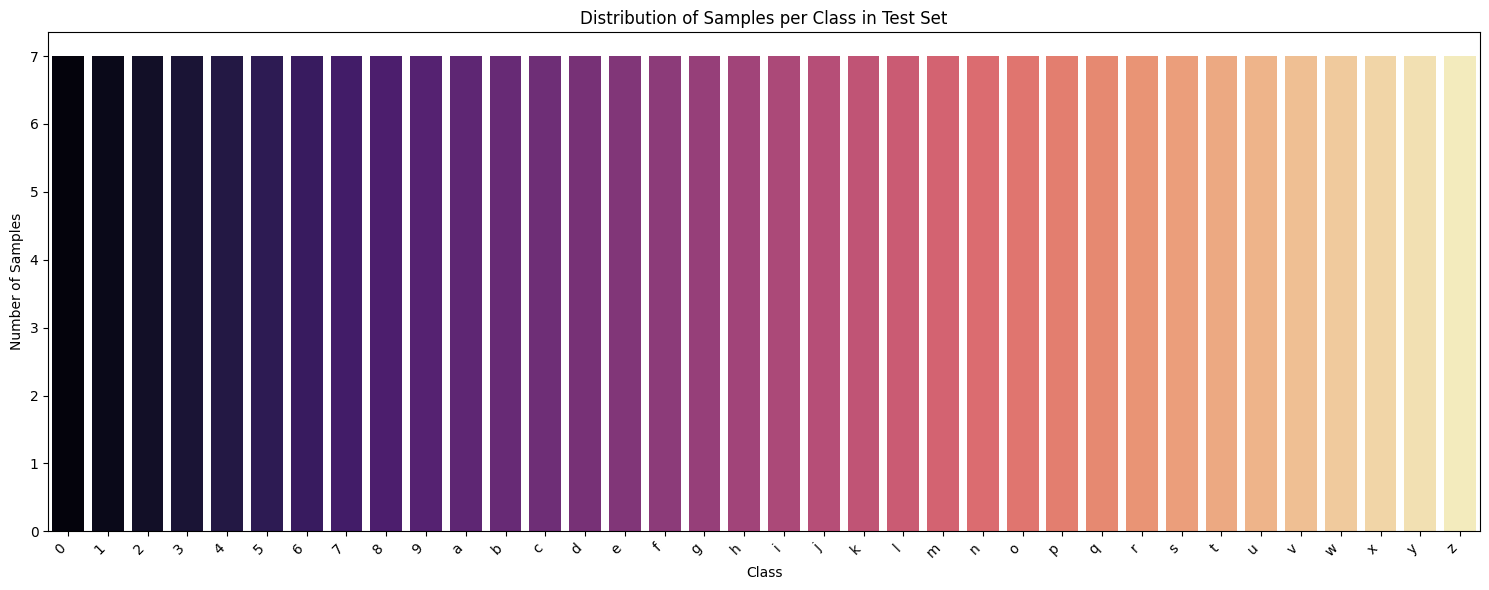

In [17]:
# Plotting the distribution for the training set
plt.figure(figsize=(15, 6))
sns.barplot(x='Class', y='Count', data=train_df, palette='viridis')
plt.title('Distribution of Samples per Class in Training Set (Augmented)')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting the distribution for the validation set
plt.figure(figsize=(15, 6))
sns.barplot(x='Class', y='Count', data=val_df, palette='plasma')
plt.title('Distribution of Samples per Class in Validation Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting the distribution for the test set
plt.figure(figsize=(15, 6))
sns.barplot(x='Class', y='Count', data=test_df, palette='magma')
plt.title('Distribution of Samples per Class in Test Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


These bar plots visually represent the number of samples for each class in your training, validation, and test datasets. You can observe the expanded size of the training set due to augmentation, and the balanced distribution across classes in all splits.

The `asl_dataset` from your Google Drive has now been restructured into `/content/asl_ultralytics_format` with `train`, `val`, and `test` directories, each containing subfolders for your classes. You can now use this format for training models with Ultralytics.

This lists the top-level items in your 'MyDrive' folder. If your folder is nested, you'll need to specify the full path (e.g., `/content/gdrive/MyDrive/MyProjectFolder`).

In [18]:
total_counts = pd.DataFrame({
    'Train': train_df.set_index('Class')['Count'],
    'Validation': val_df.set_index('Class')['Count'],
    'Test': test_df.set_index('Class')['Count']
}).fillna(0).astype(int)

total_counts['Total'] = total_counts.sum(axis=1)

print("Total Images per Class Across All Splits:")
display(total_counts.sort_index())

Total Images per Class Across All Splits:


,Train,Validation,Test,Total
Class,,,,
0,165,8,7,180
1,165,8,7,180
2,165,8,7,180
3,165,8,7,180
4,165,8,7,180
5,165,8,7,180
6,165,8,7,180
7,165,8,7,180
8,165,8,7,180


### Create `data.yaml` for Ultralytics

In [19]:
import yaml

# The class_names list is already available from previous cells.
# If not, you would need to regenerate it:
# class_names = sorted([d for d in os.listdir(os.path.join(ultralytics_dataset_path, 'train')) if os.path.isdir(os.path.join(ultralytics_dataset_path, 'train', d))])


data_yaml_content = {
    'path': ultralytics_dataset_path, # Root directory of the dataset
    'train': 'train', # Training images relative to 'path'
    'val': 'val', # Validation images relative to 'path'
    'test': 'test', # Test images relative to 'path' (optional for training)
    'nc': len(class_names), # Number of classes
    'names': sorted(class_names) # Class names
}

data_yaml_path = os.path.join(ultralytics_dataset_path, 'data.yaml')

with open(data_yaml_path, 'w') as file:
    yaml.dump(data_yaml_content, file, default_flow_style=False)

print(f"'data.yaml' created at: {data_yaml_path}")
with open(data_yaml_path, 'r') as file:
    print("\nContent of data.yaml:")
    print(file.read())

'data.yaml' created at: /content/asl_ultralytics_format/data.yaml

Content of data.yaml:
names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'
- a
- b
- c
- d
- e
- f
- g
- h
- i
- j
- k
- l
- m
- n
- o
- p
- q
- r
- s
- t
- u
- v
- w
- x
- y
- z
nc: 36
path: /content/asl_ultralytics_format
test: test
train: train
val: val



### Train YOLOv8 Model

Now that the `data.yaml` is ready, we can initiate the YOLOv8 model training. I'll use `yolov8n.pt` (nano version) as the pre-trained model for a quick start, and set some common hyperparameters.

- `data`: Path to the `data.yaml` file.
- `epochs`: Number of training epochs.
- `imgsz`: Input image size.
- `batch`: Batch size.
- `name`: Name for the training run.
- `device`: Set to `0` for GPU training if available, or `cpu`.


In [27]:
from ultralytics import YOLO
import torch

# Load a pre-trained YOLOv8n model
model = YOLO('yolo26n-cls.pt') # You can choose other models like yolov8s.pt, yolov8m.pt, etc.

# Determine device (GPU if available, else CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Train the model
results = model.train(
    data="/content/asl_ultralytics_format",
    epochs=20, # A common starting point for epochs
    imgsz=256, # Image size, align with your preprocessing or choose a suitable size
    batch=16, # Adjust based on your GPU memory
    name='asl_recognition_yolov8n_augmented',
    device=device, # Use detected device
    # Additional hyperparameters you might consider:
    # lr0=0.01, # Initial learning rate
    # optimizer='SGD', # AdamW, SGD, RMSProp
    # weight_decay=0.0005,
    # augment=False, # We already performed augmentation, so set to False to avoid double augmentation
)

print("Training complete!")

Using device: cpu
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/asl_ultralytics_format, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=asl_recognition_yolov8n_augmented-2, nbs=64, nms=False, opset=None, optimize=F